participation in class

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
%pushd "/content/drive/MyDrive/MSSP607/Modules/Week10/"


/content/drive/MyDrive/MSSP607/Modules/Week10


['/content']

In [27]:
# 0) setting
# =========================================
import os, re
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms.community import greedy_modularity_communities

SEED = 42
np.random.seed(SEED)

member = "/content/drive/MyDrive/MSSP607/Modules/Week10/students_group2.csv"
base_dir = os.path.dirname(member)  # /content/drive/MyDrive/MSSP607/Modules/Week10
students_path = os.path.join(base_dir, "students_group2.csv")
edges_path    = os.path.join(base_dir, "connections_group2.csv")

df = pd.read_csv(member)
df.head()



,Student_ID,Name,Age,Gender,Major,Year,Interests
0,1,Maggie Zhang,23,F,MSSP+DA,1st,Painting
1,2,Hanqing Sun,22,F,MSSP+DA,1st,cooking
2,3,Yijing Sun,22,F,MSSP+DA,1st,sking
3,4,Yangruoya Wang,21,F,MSSP+DA,1st,writing
4,5,YuzhenYang,23,M,MSSP+DA,1st,sleeping


In [28]:

# Configure plotting in Jupyter
from matplotlib import pyplot as plt
%matplotlib inline
plt.rcParams.update({
    'figure.figsize': (7.5, 7.5),
    'axes.spines.right': False,
    'axes.spines.left': False,
    'axes.spines.top': False,
    'axes.spines.bottom': False})
# Seed random number generator
import random
from numpy import random as nprand

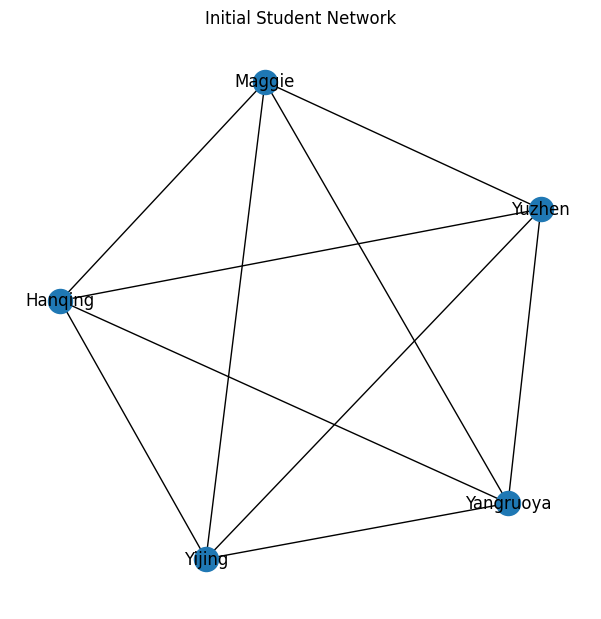

In [29]:
# 1) reading data
# =========================================
students = pd.read_csv(students_path)
edges    = pd.read_csv(edges_path)


# 2) visualization setting
# =========================================
G = nx.Graph()
# node
G.add_node('Maggie')
G.add_nodes_from(['Yangruoya', 'Yijing','Hanqing','Yuzhen'])
# edges
G.add_edges_from([
    ('Maggie', 'Yangruoya'), ('Maggie', 'Yijing'),
    ('Maggie', 'Hanqing'),   ('Maggie', 'Yuzhen'),
    ('Yangruoya', 'Yijing'), ('Yangruoya', 'Hanqing'),
    ('Yangruoya', 'Yuzhen'), ('Yijing', 'Hanqing'),
    ('Yijing', 'Yuzhen'),    ('Hanqing', 'Yuzhen')
])
# visualization
plt.figure(figsize=(7.5, 7.5))
pos = nx.spring_layout(G, seed=SEED)
nx.draw_networkx(G, pos=pos)
plt.title("Initial Student Network")
plt.axis('off')
plt.show()


In [30]:
# 3) Write the "student attribute" of the CSV to the node
def norm_letters(s: str) -> str:
    return re.sub(r'[^a-z]+', '', str(s).lower())

# Name
if "Name" not in students.columns:
    students.rename(columns={students.columns[0]: "Name"}, inplace=True)

# Extract the short name (the first word of the name)
students["FirstToken"] = students["Name"].map(lambda x: str(x).split()[0])
students["first_norm"] = students["FirstToken"].map(norm_letters)
students["full_norm"]  = students["Name"].map(norm_letters)

# Establish mapping: Short name specification string -> row record
first_map = {row["first_norm"]: row for _, row in students.iterrows()}
full2first = {row["Name"]: row["FirstToken"] for _, row in students.iterrows()}

# Write the attributes to the nodes of the graph (matching by short name)
for n in list(G.nodes()):
    n_norm = norm_letters(n)
    row = first_map.get(n_norm, None)
    if row is not None:
        for k, v in row.items():
            if k in ("first_norm","full_norm"):
                continue
            G.nodes[n][k] = v
    else:
        print(f"Rows where node '{n}' cannot be matched in the student table will only retain the node name.")

Rows where node 'Yuzhen' cannot be matched in the student table will only retain the node name.


In [31]:
# 4) Write the edge attributes of the CSV (including the connection type) to the existing edges
# =========================================
# test nodes
u_candidates = ["Student_ID_1","Source","source","from","A","u"]
v_candidates = ["Student_ID_2","Target","target","to","B","v"]

def pick_col(df, cands):
    for c in cands:
        if c in df.columns: return c
    return df.columns[0]

u_col = pick_col(edges, u_candidates)
v_col = pick_col(edges, v_candidates)

# Find the connection type field
conn_keys = ["Connection_type", "connection_type", "Type", "type", "Connection", "Connection_tyoe"]
conn_key = next((k for k in conn_keys if k in edges.columns), None)
if conn_key is None:
    raise KeyError("在 connections_group2.csv 中未找到连接类型列（如 Connection_tyoe）")

# constructure ID -> short name mapping
id2first = {}
if "Student_ID" in students.columns:
    id2first = dict(zip(students["Student_ID"].astype(str), students["FirstToken"].astype(str)))
# Write the edge attributes of the CSV to G (match by short name)
wrote = 0
for _, r in edges.iterrows():
    u_raw, v_raw = str(r[u_col]), str(r[v_col])

    # if ID， mapping with short name
    u_name = id2first.get(u_raw, u_raw.split()[0])
    v_name = id2first.get(v_raw, v_raw.split()[0])
    if u_name == v_name:
        continue

    if G.has_edge(u_name, v_name):
        G.edges[u_name, v_name][conn_key] = r[conn_key]
        for k in edges.columns:
            if k not in (u_col, v_col, conn_key):
                G.edges[u_name, v_name][k] = r[k]
        wrote += 1

print(f"[infor] {wrote} already writed the edges by categries.")

# test distribution
from collections import Counter
etype_cnt = Counter([G.edges[e].get(conn_key, "Unknown") for e in G.edges])
print("Edge types in G:", dict(etype_cnt))

[infor] 6 already writed the edges by categries.
Edge types in G: {'Classmate': 4, 'Friend': 2, 'Unknown': 4}


/tmp/ipython-input-2709780658.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", max(len(unique_types), 1))


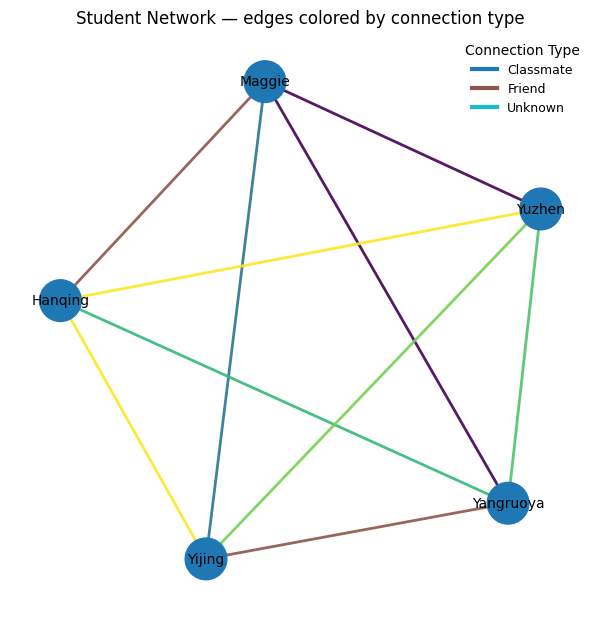

saving： /content/drive/MyDrive/MSSP607/Modules/Week10/network_edges_by_type.png


In [32]:
# 5) color edges by connection relationship
# =========================================
# categroies
edge_types = [G.edges[e].get(conn_key, "Unknown") for e in G.edges]
unique_types = sorted(set(edge_types))

# color（tab10）
cmap = plt.cm.get_cmap("tab10", max(len(unique_types), 1))
type2color = {t: cmap(i % 10) for i, t in enumerate(unique_types)}

# categroical edge
type2edges = {t: [] for t in unique_types}
for u, v, data in G.edges(data=True):
    t = data.get(conn_key, "Unknown")
    type2edges.setdefault(t, []).append((u, v))

# duplicate pos
plt.figure(figsize=(7.5, 7.5))
sizes = [300 + 150*G.degree(n) for n in G.nodes()]
nx.draw_networkx_nodes(G, pos=pos, node_size=sizes)
nx.draw_networkx_labels(G, pos=pos, font_size=10)

for t, edgelist in type2edges.items():
    nx.draw_networkx_edges(G, pos=pos, edgelist=edgelist, width=2.0, edge_color=type2color[t], alpha=0.9)

plt.title("Student Network — edges colored by connection type", fontsize=12)
plt.axis('off')
from matplotlib.lines import Line2D
handles = [Line2D([0],[0], color=type2color[t], lw=3, label=str(t)) for t in unique_types]
plt.legend(handles=handles, title="Connection Type", loc="best", frameon=False, fontsize=9)

colored_path = os.path.join(base_dir, "network_edges_by_type.png")
plt.savefig(colored_path, bbox_inches="tight", dpi=150)
plt.show()
print("saving：", colored_path)

In [33]:
# 6) management and saving CSV
# =========================================
deg_c = nx.degree_centrality(G)
clo_c = nx.closeness_centrality(G)
btw_c = nx.betweenness_centrality(G)
clust = nx.clustering(G)

metrics = pd.DataFrame({
    "node": list(G.nodes()),
    "degree": [G.degree(n) for n in G.nodes()],
    "degree_centrality": [deg_c[n] for n in G.nodes()],
    "closeness": [clo_c[n] for n in G.nodes()],
    "betweenness": [btw_c[n] for n in G.nodes()],
    "clustering": [clust[n] for n in G.nodes()],
}).sort_values(["degree","degree_centrality"], ascending=False)

UG = G.to_undirected()
components = list(nx.connected_components(UG))
components_sizes = sorted([len(c) for c in components], reverse=True)
largest = max(components, key=len) if components else set()
diameter = None; furthest_pair = None
if len(largest) >= 2:
  subG = UG.subgraph(largest).copy()
  dists = dict(nx.all_pairs_shortest_path_length(subG))
  max_len = -1
  for s, d in dists.items():
        for t, L in d.items():
            if L > max_len:
                max_len = L; furthest_pair = (s, t)
  diameter = max_len

print("Connected components sizes:", components_sizes)
print("Diameter (largest component):", diameter, "furthest pair:", furthest_pair)

communities = list(greedy_modularity_communities(UG))
comm_map = {}
for cid, com in enumerate(communities):
    for n in com: comm_map[n] = cid
nx.set_node_attributes(G, comm_map, "community")
print(f"Detected {len(communities)} communities")

metrics_path     = os.path.join(base_dir, "metrics_group2.csv")
communities_path = os.path.join(base_dir, "communities_group2.csv")
metrics.to_csv(metrics_path, index=False)
(pd.DataFrame(sorted([(n, G.nodes[n].get("community",-1)) for n in G.nodes()], key=lambda x:x[1]),
             columns=["node","community"])
 ).to_csv(communities_path, index=False)

print("save CSV：")
print(" -", metrics_path)
print(" -", communities_path)

Connected components sizes: [5]
Diameter (largest component): 1 furthest pair: ('Maggie', 'Yangruoya')
Detected 1 communities
save CSV：
 - /content/drive/MyDrive/MSSP607/Modules/Week10/metrics_group2.csv
 - /content/drive/MyDrive/MSSP607/Modules/Week10/communities_group2.csv
